In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import numpy as np
import xml.etree.ElementTree as ET

img_size = 224
#reduced from 448 to reduce memory
s = 7
b = 2

folder_path = '/content/drive/My Drive/VOC2007'

classes= ["aeroplane","bicycle","bird","boat","bottle","bus","car","cat",
    "chair","cow","diningtable","dog","horse","motorbike","person",
    "pottedplant","sheep","sofa","train","tvmonitor"]

def load_image_ids (voc_root):
    path = os.path.join(voc_root , "ImageSets" , "Main", "trainval.txt")
    with open(path) as f:
        return[line.strip() for line in f.readlines()]

def load_image(voc_root , image_id):
    path = os.path.join(voc_root ,"JPEGImages" , image_id + ".jpg")
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    return preprocess_input(img.astype(np.float32))

def parse_annotation(voc_root, image_id):
    path = os.path.join(voc_root, "Annotations" , image_id + ".xml")
    tree = ET.parse(path)
    root = tree.getroot()

    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)

    boxes, labels = [] , []

    for obj in root.findall("object"):
        label = obj.find("name").text
        if label not in classes:
          continue
        box = obj.find("bndbox")
        xmin = (float(box.find("xmin").text)/width)*img_size
        ymin = (float(box.find("ymin").text)/height)*img_size
        xmax = (float(box.find("xmax").text)/width)*img_size
        ymax = (float(box.find("ymax").text)/height)*img_size
        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(label)

    return boxes, labels

def encode_yolo_target(boxes, labels, img_size=224, S=7, B=2, C=20):
    target = np.zeros((S, S, B*5 + C), dtype=np.float32)

    cell_size = img_size / S

    for box, label in zip(boxes, labels):
        xmin, ymin, xmax, ymax = box
        x_center = (xmin + xmax) / 2.0
        y_center = (ymin + ymax) / 2.0
        w = xmax - xmin
        h = ymax - ymin

        i = min(int(y_center / cell_size), s-1)
        j = min(int(x_center / cell_size),s-1)

        x_cell = (x_center - j * cell_size) / cell_size
        y_cell = (y_center - i * cell_size) / cell_size

        w_norm = w / img_size
        h_norm = h / img_size
        class_id = classes.index(label)

        target[i, j, 0:5] = [x_cell, y_cell, w_norm, h_norm, 1.0]
        target[i, j, B*5 + class_id] = 1.0


    return target


In [ ]:
import tensorflow as tf
import keras
from keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

def conv(x , f, k , s= 1):
    x = layers.Conv2D(f, k , s, padding = "same" , use_bias = False)(x)
    x = layers.BatchNormalization()(x)
    return layers.LeakyReLU(0.1)(x)

def yolov1():
  base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
  base_model.trainable = False

  x = base_model.output

  x = layers.Conv2D(1024,3, padding = "same" , use_bias = False)(x)
  x = layers.BatchNormalization()(x)
  x = layers.LeakyReLU(0.1)(x)

  x = layers.Flatten()(x)
  x = layers.Dense(4096)(x)
  x = layers.LeakyReLU(0.1)(x)
  x = layers.Dropout(0.5)(x)

  x = layers.Dense(7*7*30, activation = "sigmoid")(x)
  out = layers.Reshape((7,7,30))(x)

  return models.Model(base_model.input, outputs= out)

if __name__ == "__main__":
    model = yolov1()
    model.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 254,013,758 (968.99 MB)

 Trainable params: 230,423,998 (879.00 MB)

 Non-trainable params: 23,589,760 (89.99 MB)

In [ ]:
import tensorflow as tf

def bbox_iou(boxes1, boxes2):
    boxes1_xy = boxes1[..., 0:2]
    boxes1_wh = boxes1[..., 2:4]
    boxes1_mins = boxes1_xy - boxes1_wh / 2.
    boxes1_maxes = boxes1_xy + boxes1_wh / 2.

    boxes2_xy = boxes2[..., 0:2]
    boxes2_wh = boxes2[..., 2:4]
    boxes2_mins = boxes2_xy - boxes2_wh / 2.
    boxes2_maxes = boxes2_xy + boxes2_wh / 2.

    intersect_mins = tf.maximum(boxes1_mins, boxes2_mins)
    intersect_maxes = tf.minimum(boxes1_maxes, boxes2_maxes)

    intersect_wh = tf.maximum(intersect_maxes - intersect_mins, 0.)
    intersect_area = intersect_wh[..., 0] * intersect_wh[..., 1]

    boxes1_area = tf.maximum(boxes1_wh[..., 0] * boxes1_wh[..., 1], 1e-10)
    boxes2_area = tf.maximum(boxes2_wh[..., 0] * boxes2_wh[..., 1], 1e-10)

    union_area = boxes1_area + boxes2_area - intersect_area
    iou = intersect_area / tf.maximum(union_area, 1e-10)

    return iou
def yolo_loss(y_true, y_pred):

    obj_mask = y_true[..., 4:5]
    no_obj_mask = 1.0 - obj_mask

    true_xy = y_true[..., 0:2]
    pred_xy = y_pred[..., 0:2]
    true_wh = y_true[..., 2:4]
    pred_wh = y_pred[..., 2:4]

    pred_wh = tf.maximum(pred_wh, 1e-6)
    xy_loss = tf.reduce_sum(tf.square(true_xy - pred_xy), axis=-1, keepdims=True)

    wh_loss = tf.reduce_sum(tf.square(tf.sqrt(true_wh + 1e-6) - tf.sqrt(tf.abs(pred_wh) + 1e-6)), axis=-1, keepdims=True)
    coord_loss = 5.0 * tf.reduce_sum(obj_mask * (xy_loss + wh_loss))

    iou_scores = bbox_iou(y_true[..., 0:4], y_pred[..., 0:4])
    true_conf_target = iou_scores[..., tf.newaxis]

    pred_conf = y_pred[..., 4:5]

    conf_loss_obj = tf.reduce_sum(obj_mask * tf.square(true_conf_target - pred_conf))

    conf_loss_noobj = 0.5 * tf.reduce_sum(no_obj_mask * tf.square(tf.zeros_like(true_conf_target) - pred_conf))

    true_class = y_true[..., 10:]
    pred_class = y_pred[..., 10:]
    class_loss = tf.reduce_sum(obj_mask * tf.square(true_class - pred_class))

    total_loss = (coord_loss + conf_loss_obj + conf_loss_noobj + class_loss)

    batch_size = tf.cast(tf.shape(y_true)[0], tf.float32)
    total_loss = tf.where(tf.math.is_finite(total_loss), total_loss, tf.zeros_like(total_loss))
    return total_loss / tf.cast(tf.shape(y_true)[0], tf.float32)

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow import keras

voc_root = '/content/drive/My Drive/VOC2007'

from keras import mixed_precision

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

ids = load_image_ids(voc_root)[:100]

def voc_generator (image_ids, voc_root, batch_size = 16):
  while True:
    np.random.shuffle(image_ids)
    for i in range(0, len(image_ids) , batch_size):
      batch_ids = image_ids[i:i+batch_size]
      x_batch,y_batch = [],[]
      for img_id in batch_ids:
        img = load_image(voc_root, img_id)
        if img is None:
          continue
        boxes, labels = parse_annotation(voc_root, img_id)
        target = encode_yolo_target(boxes, labels)
        x_batch.append(img)
        y_batch.append(target)

     if len(x_batch) > 0:
         yield np.array(x_batch, dtype=np.float32), np.array(y_batch, dtype=np.float32)

all_ids = load_image_ids(voc_root)
train_gen = voc_generator(all_ids, voc_root, batch_size = 16)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4045s 13s/step - loss: 29.0480
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 67s 174ms/step - loss: 24.1787
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 174ms/step - loss: 21.1692
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 173ms/step - loss: 19.1174
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 174ms/step - loss: 17.9124


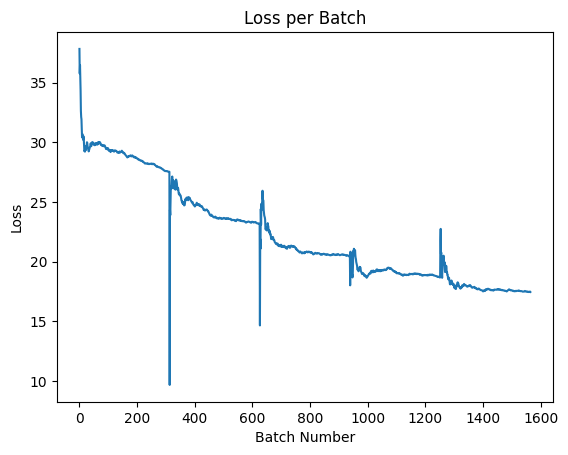

In [ ]:
import keras
import matplotlib.pyplot as plt

class LossHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.losses = []

    def on_batch_end(self, batch, logs={}):
        self.losses.append(logs.get('loss'))

history_callback = LossHistory()

model = yolov1()
model.compile(optimizer =tf.keras.optimizers.Adam(learning_rate = 1e-7), loss = yolo_loss)
history = model.fit(train_gen, steps_per_epoch = (len(all_ids)//16),epochs = 5, callbacks = [history_callback])


# After training completes, you can access the list of batch losses
all_batch_losses = history_callback.losses

# Plot the batch losses
plt.plot(all_batch_losses)
plt.title('Loss per Batch')
plt.xlabel('Batch Number')
plt.ylabel('Loss')
plt.show()

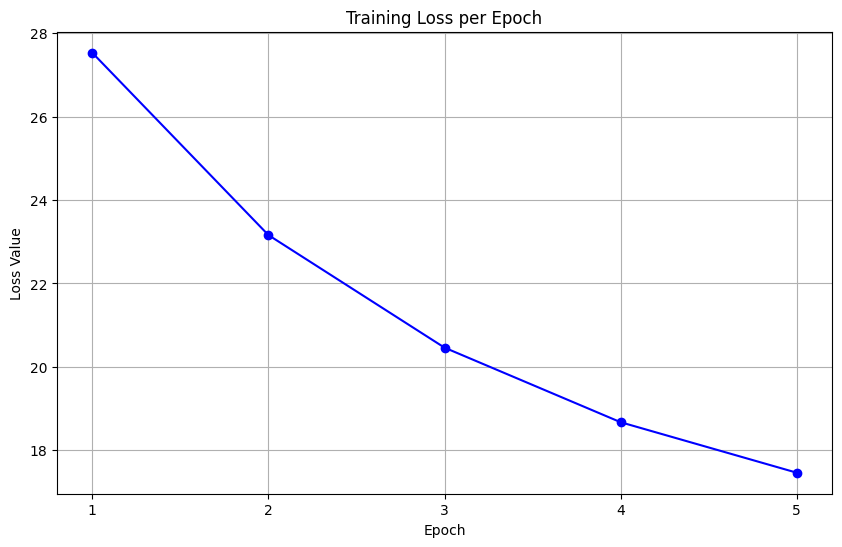

In [ ]:
import matplotlib.pyplot as plt
loss_values = history.history['loss']

epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss_values, marker='o', linestyle='-', color='b')


plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.grid(True)
plt.xticks(epochs)

plt.show()

In [ ]:
import numpy as np
import cv2

img_size = 224
s = 7
b = 2
c = 20

classes = ["aeroplane","bicycle","bird","boat","bottle","bus","car","cat",
    "chair","cow","diningtable","dog","horse","motorbike","person",
    "pottedplant","sheep","sofa","train","tvmonitor"]

def decode_predictions(pred, conf_threshold = 0.001):
    boxes = []
    cell_size = img_size/s

    for j in range(s):
        for i in range(s):
            cell = pred[j,i]

            confidence = cell[4]
            if confidence < conf_threshold:
                continue
            x,y,w,h = cell[0:4]
            class_probs = cell[10:]
            class_id = np.argmax(class_probs)
            score = confidence * class_probs[class_id]

            cx = (i+x)*cell_size
            cy = (j+y)*cell_size
            bw = w*img_size
            bh = h*img_size

            xmin = int(cx-bw/2)
            ymin = int(cy-bh /2)
            xmax = int(cx+bw / 2)
            ymax = int(cy+bh / 2)

            class_id = np.argmax(class_probs)
            score = confidence * class_probs[class_id]

            boxes.append([xmin, ymin, xmax, ymax, score, class_id])

        return boxes

def draw_boxes(image, boxes):
    img = image.copy()

    for box in boxes:
        xmin, xmax,ymin,ymax, score, class_id = box
        label = classes[class_id]

        cv2.rectangle(img, (xmin,ymin), (xmax, ymax), (0,255,0) , 2)
        cv2.putText(img, f"{label} {score:.2f}",(xmin, max(ymin - 5, 0)),
            cv2.FRONT_HERSHEY_SIMPLEX,
            0.4,(255,255,255),1)
    return img


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
RAW BOX (0,0): [0.7803  0.827   0.06143 0.7397 ]
RAW BOX (3,3): [0.436  0.8125 0.679  0.2404]
RAW BOX (6,6): [0.5083 0.4822 0.1476 0.1962]


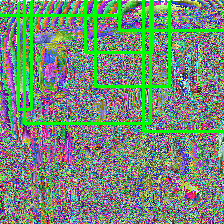

<function destroyAllWindows>

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

voc_root = '/content/drive/My Drive/VOC2007'

# Redefining draw_boxes function with the fix for FRONT_HERSHEY_SIMPLEX
def draw_boxes(image, boxes):
    img = image.copy()

    for box in boxes:
        xmin, ymin, xmax, ymax, score, class_id = box
        label = classes[class_id]

        cv2.rectangle(img, (xmin,ymin), (xmax, ymax), (0,255,0) , 2)
        cv2.putText(img, f"{label} {score:.2f}",(xmin, max(ymin - 5, 0)),
            cv2.FONT_HERSHEY_SIMPLEX, # Corrected from FRONT_HERSHEY_SIMPLEX
            0.4,(255,255,255),1)
    return img

model = yolov1()
model.load_weights("yolo_temp.weights.h5") if False else None

ids = load_image_ids(voc_root)
image_id = ids[0]

image = load_image(voc_root, image_id)
input_tensor = np.expand_dims(image, axis = 0)

pred = model.predict(input_tensor)[0]
boxes = decode_predictions(pred, conf_threshold = 0.001)

output_img = draw_boxes((image*225).astype(np.uint8),boxes)

pred = model.predict(image[None, ...])[0]

print("RAW BOX (0,0):", pred[0,0,0:4])
print("RAW BOX (3,3):", pred[3,3,0:4])
print("RAW BOX (6,6):", pred[6,6,0:4])

cv2_imshow(output_img)
cv2.waitKey(0)
cv2.destroyAllWindows

In [ ]:
small_ids = load_image_ids(voc_root)[:1]
small_train_gen = voc_generator(small_ids, voc_root, batch_size=1)

model_debug = yolov1()
model_debug.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss=yolo_loss)

print("Starting debug training")
history_debug = model_debug.fit(small_train_gen, steps_per_epoch=len(small_ids), epochs=1, verbose=1)
print("Debug training finished")
print("Debug history loss:", history_debug.history['loss'])

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Debug Training Loss')
plt.title('Debug Training Loss over Epochs')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()